# EE 446 TinyML — Model Pruning with Quantization  
## Student TODO Version: Pruning and Quantization of a DNN Using the UCI Human Activity Recognition Dataset

### Overview
In this notebook, you will:
- train a baseline DNN on the **UCI HAR** dataset,
- apply **magnitude-based pruning**,
- compare the pruned model before and after `strip_pruning(...)`, and
- combine pruning with **float16 quantization**.

Use the **`Python (tinyml-arduino)`** Jupyter kernel for this notebook.


## 1. Environment Setup

This notebook is designed to run with the **`Python (tinyml-arduino)`** Jupyter kernel that you already created.

This notebook assumes the environment already contains:
- `tensorflow==2.14.1`
- `tensorflow-model-optimization==0.8.0`
- `numpy`, `pandas`, `matplotlib`, and `scikit-learn`

Do **not** reinstall TensorFlow packages inside the notebook if you are already using the working TinyML environment.


In [3]:
import os
import math
import zipfile
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python executable:", os.sys.executable)
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


Python executable: /Users/wenjeffery/ai/projects/tinyml-arduino/bin/python
TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 2. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals,
- **6 activity classes**, and
- predefined **training** and **test** splits.

The code below downloads and extracts the dataset if it is not already present in the working directory.


In [5]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    urllib.request.urlretrieve(dataset_url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 3. Load the Data

In [7]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt as float32
    # 2. Load y_train from train/y_train.txt as int32
    # 3. Load X_test from test/X_test.txt as float32
    # 4. Load y_test from test/y_test.txt as int32
    # 5. Convert labels to zero-based class indices by subtracting 1

    # <-- Enter your code here <--#
    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt")).astype(np.float32)
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt")).astype(np.int32) - 1
    X_test  = np.loadtxt(os.path.join(root_dir, "test",  "X_test.txt")).astype(np.float32)
    y_test  = np.loadtxt(os.path.join(root_dir, "test",  "y_test.txt")).astype(np.int32) - 1
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO:
# Define num_features and num_classes.
# Print the train/test shapes and the number of features/classes.

# <-- Enter your code here <--#
num_features = X_train.shape[1]
num_classes  = len(class_names)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test: ", X_test.shape,  "y_test: ", y_test.shape)
print("num_features:", num_features, "| num_classes:", num_classes)

X_train: (7352, 561) y_train: (7352,)
X_test:  (2947, 561) y_test:  (2947,)
num_features: 561 | num_classes: 6


## 4. Quick Inspection

In [9]:
# TODO:
# Create a small summary table showing:
# - class index,
# - class name, and
# - number of training samples in each class.

# <-- Enter your code here <--#
summary_df = pd.DataFrame({
    "Class Index": range(num_classes),
    "Class Name": class_names,
    "Training Samples": [int(np.sum(y_train == i)) for i in range(num_classes)]
})
print(summary_df.to_string(index=False))

 Class Index         Class Name  Training Samples
           0            WALKING              1226
           1   WALKING_UPSTAIRS              1073
           2 WALKING_DOWNSTAIRS               986
           3            SITTING              1286
           4           STANDING              1374
           5             LAYING              1407


## 5. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [11]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    # <-- Enter your code here <--#
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax'),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model

In [13]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#
baseline_history = baseline_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/40
92/92 [==============================] - 1s 3ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 2ms/step - loss: 0.1638 - accuracy: 0.9374 - val_loss: 0.1399 - val_accuracy: 0.9375
Epoch 3/40
92/92 [==============================] - 0s 2ms/step - loss: 0.1152 - accuracy: 0.9568 - val_loss: 0.2632 - val_accuracy: 0.9123
Epoch 4/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0907 - accuracy: 0.9633 - val_loss: 0.1618 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0905 - accuracy: 0.9646 - val_loss: 0.2719 - val_accuracy: 0.9205
Epoch 6/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0712 - accuracy: 0.9723 - val_loss: 0.2235 - val_accuracy: 0.9307
Epoch 7/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0588 - accuracy: 0.9776 - val_loss: 0.1442 - val_accuracy: 0.9422
Epoch 8/40
92/92 [==

### Training Curves

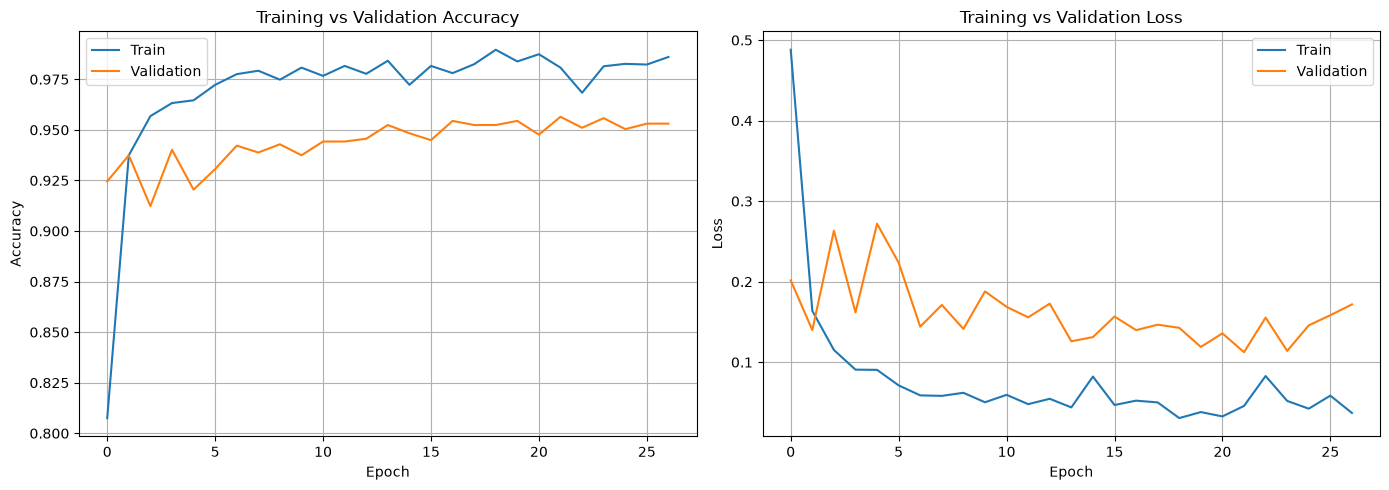

In [15]:
# TODO:
# Plot:
# 1. training accuracy vs validation accuracy
# 2. training loss vs validation loss

# <-- Enter your code here <--#
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(baseline_history.history['accuracy'], label='Train')
ax1.plot(baseline_history.history['val_accuracy'], label='Validation')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.set_title('Training vs Validation Accuracy'); ax1.legend(); ax1.grid(True)
ax2.plot(baseline_history.history['loss'], label='Train')
ax2.plot(baseline_history.history['val_loss'], label='Validation')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.set_title('Training vs Validation Loss'); ax2.legend(); ax2.grid(True)
plt.tight_layout()
plt.show()

## 6. Evaluate the Baseline Keras Model

Baseline Test Accuracy: 0.9264

                    precision    recall  f1-score   support

           WALKING     0.8591    0.9960    0.9225       496
  WALKING_UPSTAIRS     0.9525    0.8514    0.8991       471
WALKING_DOWNSTAIRS     0.9721    0.9119    0.9410       420
           SITTING     0.9315    0.8859    0.9081       491
          STANDING     0.8724    0.9380    0.9040       532
            LAYING     1.0000    0.9646    0.9820       537

          accuracy                         0.9264      2947
         macro avg     0.9313    0.9246    0.9261      2947
      weighted avg     0.9303    0.9264    0.9265      2947



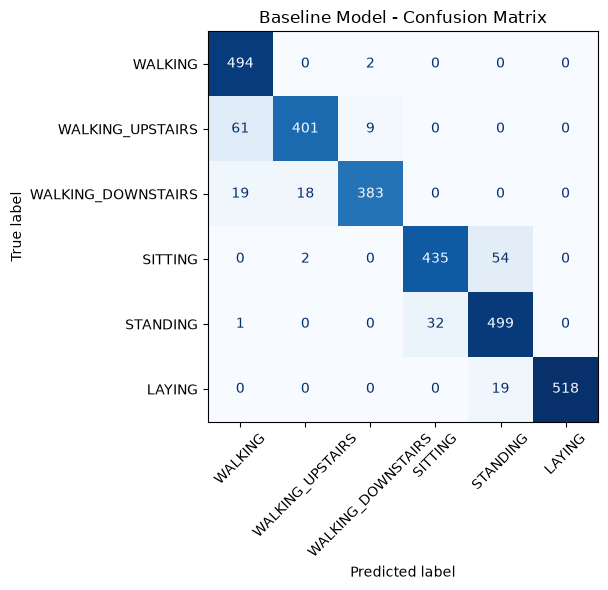

In [17]:
# TODO:
# 1. Predict class probabilities on X_test
# 2. Convert probabilities to class labels using argmax
# 3. Compute the test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#
y_probs = baseline_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_probs, axis=1)

test_acc = accuracy_score(y_test, y_pred)
print(f"Baseline Test Accuracy: {test_acc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues', colorbar=False)
plt.title('Baseline Model - Confusion Matrix')
plt.tight_layout()
plt.show()

# Part I: Model Pruning with Sparsity

In this part, we apply **magnitude-based pruning** to the DNN. The key idea is to gradually set small-magnitude weights to zero during training.

We will compare:
1. the baseline TensorFlow Lite model,
2. the pruned model converted **without** stripping the pruning wrappers, and
3. the stripped sparse model converted with **experimental sparsity-aware optimization**.


## 7. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model size.


In [20]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the TFLite input tensor expects int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        # <-- Enter your code here <--#
        if input_details["dtype"] in (np.int8, np.uint8):
            x = np.round(x / input_scale + input_zero_point).astype(input_details["dtype"])
        else:
            x = x.astype(input_details["dtype"])

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # Dequantize the output only when the output tensor is int8 or uint8.

        # <-- Enter your code here <--#
        if output_details["dtype"] in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    # TODO:
    # Create a TFLiteConverter from the Keras model and return the converted FP32 model bytes.

    # <-- Enter your code here <--#
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    return converter.convert()

## 8. Convert the Baseline Model to TensorFlow Lite

In [22]:
# TODO:
# Convert the baseline model to FP32 TensorFlow Lite.
# Save the .tflite file, compute its size in KB, and evaluate it on X_test.

# <-- Enter your code here <--#
baseline_fp32_tflite = convert_to_tflite_fp32(baseline_model)
baseline_fp32_size_kb = save_binary_model(baseline_fp32_tflite, "baseline_fp32.tflite")
baseline_fp32_acc, _ = evaluate_tflite_model(baseline_fp32_tflite, X_test, y_test)
print(f"Baseline FP32 TFLite Accuracy: {baseline_fp32_acc:.4f}, Size: {baseline_fp32_size_kb:.2f} KB")

INFO:tensorflow:Assets written to: /var/folders/fj/nl8255ks72q1fqvbmxpqtmxh0000gn/T/tmp8ygw7554/assets


INFO:tensorflow:Assets written to: /var/folders/fj/nl8255ks72q1fqvbmxpqtmxh0000gn/T/tmp8ygw7554/assets
2026-07-13 21:38:05.160580: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-13 21:38:05.160612: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-13 21:38:05.160897: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/fj/nl8255ks72q1fqvbmxpqtmxh0000gn/T/tmp8ygw7554
2026-07-13 21:38:05.161533: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-13 21:38:05.161539: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/fj/nl8255ks72q1fqvbmxpqtmxh0000gn/T/tmp8ygw7554
2026-07-13 21:38:05.163043: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:382] MLIR V1 optimization pass is not enabled
2026-07-13 21:38:05.163711: I tensorflow/cc/saved_model/load

Baseline FP32 TFLite Accuracy: 0.9264, Size: 726.72 KB


## 9. Apply Magnitude-Based Pruning

We will prune the DNN using a **polynomial decay schedule**:
- start from low sparsity,
- gradually increase sparsity during training, and
- finish with a highly sparse model.

After training, we will compare:
- the pruned model **with** the pruning wrappers still present, and
- the final sparse model after applying `strip_pruning(...)`.


In [24]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

pruning_epochs = 12
batch_size = 64

# TODO:
# Compute steps_per_epoch using 80% of the training set and the selected batch size.
# Define pruning_params using PolynomialDecay with:
# - initial_sparsity=0.20
# - final_sparsity=0.85
# - begin_step=0
# - end_step=steps_per_epoch * pruning_epochs

# <-- Enter your code here <--#
steps_per_epoch = math.ceil((0.8 * len(X_train)) / batch_size)

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=steps_per_epoch * pruning_epochs,
    )
}

# TODO:
# Create the pruned model by wrapping a fresh baseline DNN with prune_low_magnitude.
# Compile it with Adam(1e-3), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#
pruned_model = prune_low_magnitude(build_baseline_model(num_features, num_classes), **pruning_params)
pruned_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the pruned model using:
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks

# <-- Enter your code here <--#
pruning_history = pruned_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks,
    verbose=1
)

Epoch 1/12
92/92 [==============================] - 1s 3ms/step - loss: 0.4751 - accuracy: 0.8067 - val_loss: 0.2226 - val_accuracy: 0.9218
Epoch 2/12
92/92 [==============================] - 0s 2ms/step - loss: 0.1662 - accuracy: 0.9367 - val_loss: 0.1591 - val_accuracy: 0.9293
Epoch 3/12
92/92 [==============================] - 0s 2ms/step - loss: 0.1314 - accuracy: 0.9493 - val_loss: 0.2293 - val_accuracy: 0.9252
Epoch 4/12
92/92 [==============================] - 0s 2ms/step - loss: 0.0901 - accuracy: 0.9699 - val_loss: 0.1750 - val_accuracy: 0.9334
Epoch 5/12
92/92 [==============================] - 0s 2ms/step - loss: 0.1388 - accuracy: 0.9476 - val_loss: 0.1383 - val_accuracy: 0.9415
Epoch 6/12
92/92 [==============================] - 0s 2ms/step - loss: 0.1209 - accuracy: 0.9607 - val_loss: 0.1783 - val_accuracy: 0.9347
Epoch 7/12
92/92 [==============================] - 0s 2ms/step - loss: 0.3121 - accuracy: 0.9255 - val_loss: 0.1751 - val_accuracy: 0.9334
Epoch 8/12
92/92 [==

## 10. Convert the Pruned Model Before and After Stripping the Pruning Wrappers

First, we convert the pruned model **with** the pruning wrappers still attached.

Next, we strip the pruning wrappers and convert the resulting sparse model with:
- `tf.lite.Optimize.EXPERIMENTAL_SPARSITY`

This is the proper way to preserve sparsity in the exported TensorFlow Lite model.


In [26]:
# TODO:
# 1. Convert the pruned model WITH the pruning wrappers still attached to FP32 TensorFlow Lite.
# 2. Save the model and evaluate it on X_test.
# 3. Strip the pruning wrappers using strip_pruning(...).
# 4. Convert the stripped model with tf.lite.Optimize.EXPERIMENTAL_SPARSITY.
# 5. Save the stripped sparse model and evaluate it on X_test.

# <-- Enter your code here <--#
# 1. Pruned with mask -> FP32 TFLite
pruned_with_mask_tflite = convert_to_tflite_fp32(pruned_model)
pruned_with_mask_size_kb = save_binary_model(pruned_with_mask_tflite, "pruned_with_mask_fp32.tflite")
pruned_with_mask_acc, _ = evaluate_tflite_model(pruned_with_mask_tflite, X_test, y_test)
print(f"Pruned (with mask) FP32 Accuracy: {pruned_with_mask_acc:.4f}, Size: {pruned_with_mask_size_kb:.2f} KB")

# 2. Strip and re-convert with sparsity optimization
stripped_model = strip_pruning(pruned_model)

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()

stripped_sparse_size_kb = save_binary_model(stripped_sparse_tflite, "stripped_sparse_fp32.tflite")
stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(stripped_sparse_tflite, X_test, y_test)
print(f"Stripped Sparse FP32 Accuracy: {stripped_sparse_acc:.4f}, Size: {stripped_sparse_size_kb:.2f} KB")

INFO:tensorflow:Assets written to: /var/folders/fj/nl8255ks72q1fqvbmxpqtmxh0000gn/T/tmpciae3aci/assets


INFO:tensorflow:Assets written to: /var/folders/fj/nl8255ks72q1fqvbmxpqtmxh0000gn/T/tmpciae3aci/assets
2026-07-13 21:38:09.892119: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-13 21:38:09.892142: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-13 21:38:09.892284: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/fj/nl8255ks72q1fqvbmxpqtmxh0000gn/T/tmpciae3aci
2026-07-13 21:38:09.894201: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-13 21:38:09.894209: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/fj/nl8255ks72q1fqvbmxpqtmxh0000gn/T/tmpciae3aci
2026-07-13 21:38:09.899560: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-13 21:38:09.938044: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

Pruned (with mask) FP32 Accuracy: 0.9376, Size: 1454.18 KB
INFO:tensorflow:Assets written to: /var/folders/fj/nl8255ks72q1fqvbmxpqtmxh0000gn/T/tmph3ja8wlr/assets


INFO:tensorflow:Assets written to: /var/folders/fj/nl8255ks72q1fqvbmxpqtmxh0000gn/T/tmph3ja8wlr/assets
2026-07-13 21:38:10.842317: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-13 21:38:10.842340: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-13 21:38:10.842478: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/fj/nl8255ks72q1fqvbmxpqtmxh0000gn/T/tmph3ja8wlr
2026-07-13 21:38:10.842936: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-13 21:38:10.842941: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/fj/nl8255ks72q1fqvbmxpqtmxh0000gn/T/tmph3ja8wlr
2026-07-13 21:38:10.843959: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-13 21:38:10.855446: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

Stripped Sparse FP32 Accuracy: 0.9376, Size: 162.99 KB


## 11. Part I Comparison: Accuracy and Model Size

In [28]:
# TODO:
# Create a comparison DataFrame for Part I with the columns:
# Model, Format, Test Accuracy, Model Size (KB)

# Include:
# - baseline FP32 TFLite
# - pruned FP32 TFLite with mask
# - stripped sparse FP32 TFLite

# <-- Enter your code here <--#
part1_df = pd.DataFrame([
    ["Baseline",           "FP32",          baseline_fp32_acc,   baseline_fp32_size_kb],
    ["Pruned (with mask)", "FP32",          pruned_with_mask_acc, pruned_with_mask_size_kb],
    ["Stripped Sparse",    "FP32 + Sparse", stripped_sparse_acc, stripped_sparse_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

print(part1_df.to_string(index=False))

             Model        Format  Test Accuracy  Model Size (KB)
          Baseline          FP32       0.926366       726.718750
Pruned (with mask)          FP32       0.937564      1454.175781
   Stripped Sparse FP32 + Sparse       0.937564       162.992188


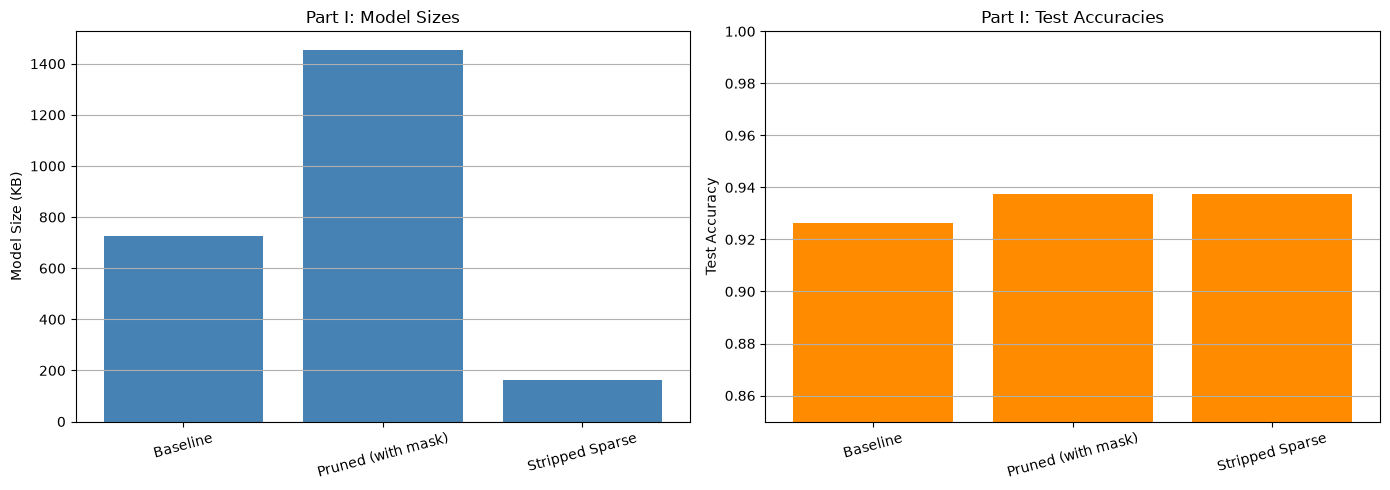

In [29]:
# TODO:
# Plot:
# 1. a bar chart of the Part I model sizes
# 2. a bar chart of the Part I test accuracies

# <-- Enter your code here <--#
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(part1_df["Model"], part1_df["Model Size (KB)"], color='steelblue')
ax1.set_ylabel("Model Size (KB)")
ax1.set_title("Part I: Model Sizes")
ax1.tick_params(axis='x', rotation=15)
ax1.grid(axis='y')

ax2.bar(part1_df["Model"], part1_df["Test Accuracy"], color='darkorange')
ax2.set_ylabel("Test Accuracy")
ax2.set_title("Part I: Test Accuracies")
ax2.tick_params(axis='x', rotation=15)
ax2.set_ylim(0.85, 1.0)
ax2.grid(axis='y')

plt.tight_layout()
plt.show()

### Confusion Matrix for the Stripped Sparse Model

                    precision    recall  f1-score   support

           WALKING     0.9265    0.9657    0.9457       496
  WALKING_UPSTAIRS     0.9408    0.9108    0.9256       471
WALKING_DOWNSTAIRS     0.9279    0.9190    0.9234       420
           SITTING     0.9208    0.9002    0.9104       491
          STANDING     0.9064    0.9286    0.9174       532
            LAYING     1.0000    0.9926    0.9963       537

          accuracy                         0.9376      2947
         macro avg     0.9371    0.9362    0.9365      2947
      weighted avg     0.9378    0.9376    0.9375      2947



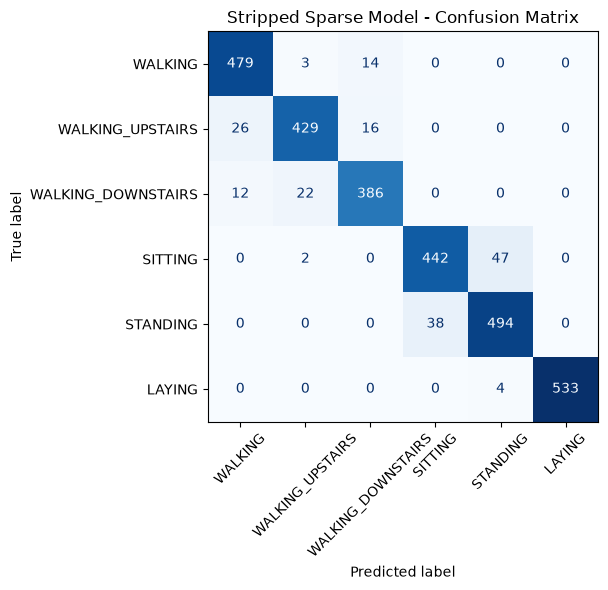

In [31]:
# TODO:
# Plot the confusion matrix for the stripped sparse TFLite model.
# Print the classification report for the stripped sparse TFLite model.

# <-- Enter your code here <--#
print(classification_report(y_test, stripped_sparse_preds, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, stripped_sparse_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues', colorbar=False)
plt.title('Stripped Sparse Model - Confusion Matrix')
plt.tight_layout()
plt.show()

# Part II: Model Pruning + Float16 Quantization

In this part, we combine **pruning** and **float16 quantization**.

We will compare:
1. the pruned TensorFlow Lite model **with** the pruning wrappers still attached, after float16 quantization, and
2. the stripped sparse TensorFlow Lite model after **both** sparsity-aware optimization and float16 quantization.

This lets us observe whether properly finalizing the pruned model leads to a more compact deployable representation.


In [33]:
# TODO:
# Part II: combine pruning and float16 quantization.
#
# 1. Convert the pruned model with mask using:
#    - optimizations = [tf.lite.Optimize.DEFAULT]
#    - supported_types = [tf.float16]
# 2. Save and evaluate the float16 model with mask.
# 3. Convert the stripped sparse model using:
#    - optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
#    - supported_types = [tf.float16]
# 4. Save and evaluate the stripped sparse + float16 model.

# <-- Enter your code here <--#
# 1. Pruned with mask + float16
converter = tf.lite.TFLiteConverter.from_keras_model(pruned_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
pruned_fp16_with_mask_tflite = converter.convert()
pruned_fp16_with_mask_size_kb = save_binary_model(pruned_fp16_with_mask_tflite, "pruned_with_mask_fp16.tflite")
pruned_fp16_with_mask_acc, _ = evaluate_tflite_model(pruned_fp16_with_mask_tflite, X_test, y_test)
print(f"Pruned (with mask) Float16 Accuracy: {pruned_fp16_with_mask_acc:.4f}, Size: {pruned_fp16_with_mask_size_kb:.2f} KB")

# 2. Stripped sparse + float16
converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
converter.target_spec.supported_types = [tf.float16]
stripped_fp16_tflite = converter.convert()
stripped_fp16_size_kb = save_binary_model(stripped_fp16_tflite, "stripped_sparse_fp16.tflite")
stripped_fp16_acc, stripped_fp16_preds = evaluate_tflite_model(stripped_fp16_tflite, X_test, y_test)
print(f"Stripped Sparse Float16 Accuracy: {stripped_fp16_acc:.4f}, Size: {stripped_fp16_size_kb:.2f} KB")

INFO:tensorflow:Assets written to: /var/folders/fj/nl8255ks72q1fqvbmxpqtmxh0000gn/T/tmp5166odmo/assets


INFO:tensorflow:Assets written to: /var/folders/fj/nl8255ks72q1fqvbmxpqtmxh0000gn/T/tmp5166odmo/assets
2026-07-13 21:38:12.303035: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-13 21:38:12.303057: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-13 21:38:12.303214: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/fj/nl8255ks72q1fqvbmxpqtmxh0000gn/T/tmp5166odmo
2026-07-13 21:38:12.305065: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-13 21:38:12.305074: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/fj/nl8255ks72q1fqvbmxpqtmxh0000gn/T/tmp5166odmo
2026-07-13 21:38:12.310184: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-13 21:38:12.349315: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

Pruned (with mask) Float16 Accuracy: 0.9376, Size: 732.59 KB
INFO:tensorflow:Assets written to: /var/folders/fj/nl8255ks72q1fqvbmxpqtmxh0000gn/T/tmp5eeuce00/assets


INFO:tensorflow:Assets written to: /var/folders/fj/nl8255ks72q1fqvbmxpqtmxh0000gn/T/tmp5eeuce00/assets
2026-07-13 21:38:13.107110: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-07-13 21:38:13.107127: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-07-13 21:38:13.107250: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/fj/nl8255ks72q1fqvbmxpqtmxh0000gn/T/tmp5eeuce00
2026-07-13 21:38:13.107616: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-07-13 21:38:13.107623: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/fj/nl8255ks72q1fqvbmxpqtmxh0000gn/T/tmp5eeuce00
2026-07-13 21:38:13.108604: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-07-13 21:38:13.119810: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

Stripped Sparse Float16 Accuracy: 0.9376, Size: 108.74 KB


## 12. Part II Comparison: Accuracy and Model Size

In [35]:
# TODO:
# Create a Part II comparison DataFrame with the columns:
# Model, Format, Test Accuracy, Model Size (KB)
#
# Include:
# - pruned FP32 with mask
# - stripped sparse FP32
# - pruned float16 with mask
# - stripped sparse float16

# <-- Enter your code here <--#
part2_df = pd.DataFrame([
    ["Pruned (with mask)", "FP32",             pruned_with_mask_acc,      pruned_with_mask_size_kb],
    ["Stripped Sparse",    "FP32 + Sparse",    stripped_sparse_acc,       stripped_sparse_size_kb],
    ["Pruned (with mask)", "Float16",          pruned_fp16_with_mask_acc, pruned_fp16_with_mask_size_kb],
    ["Stripped Sparse",    "Float16 + Sparse", stripped_fp16_acc,         stripped_fp16_size_kb],
], columns=["Model", "Format", "Test Accuracy", "Model Size (KB)"])

print(part2_df.to_string(index=False))

             Model           Format  Test Accuracy  Model Size (KB)
Pruned (with mask)             FP32       0.937564      1454.175781
   Stripped Sparse    FP32 + Sparse       0.937564       162.992188
Pruned (with mask)          Float16       0.937564       732.585938
   Stripped Sparse Float16 + Sparse       0.937564       108.742188


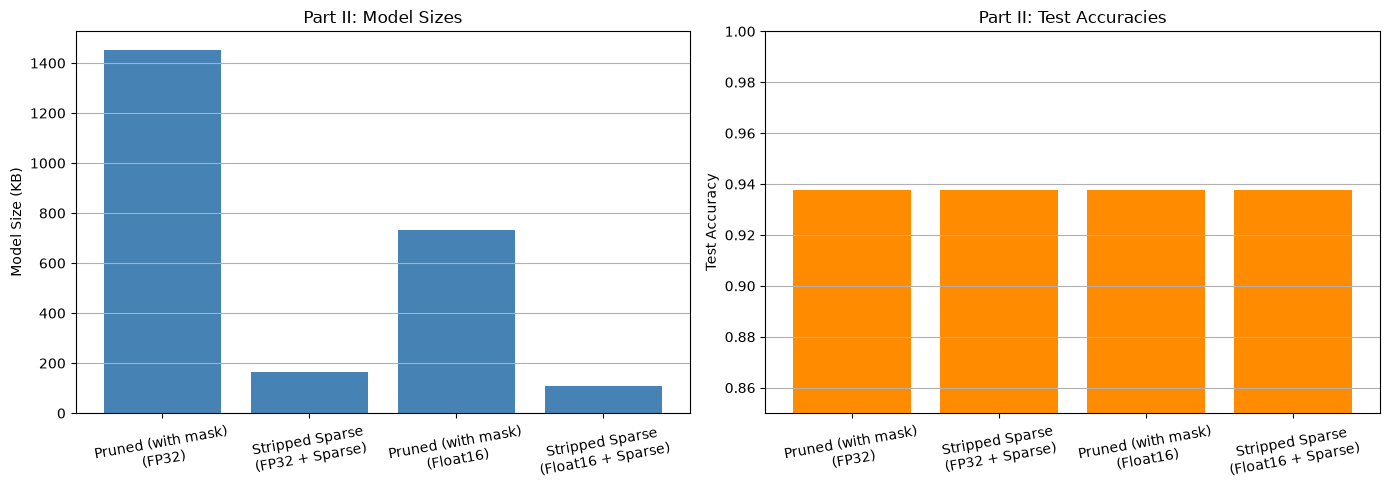

In [36]:
# TODO:
# Plot:
# 1. a bar chart of Part II model sizes
# 2. a bar chart of Part II test accuracies

# <-- Enter your code here <--#
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
labels = [f"{r['Model']}\n({r['Format']})" for _, r in part2_df.iterrows()]

ax1.bar(labels, part2_df["Model Size (KB)"], color='steelblue')
ax1.set_ylabel("Model Size (KB)")
ax1.set_title("Part II: Model Sizes")
ax1.tick_params(axis='x', rotation=10)
ax1.grid(axis='y')

ax2.bar(labels, part2_df["Test Accuracy"], color='darkorange')
ax2.set_ylabel("Test Accuracy")
ax2.set_title("Part II: Test Accuracies")
ax2.tick_params(axis='x', rotation=10)
ax2.set_ylim(0.85, 1.0)
ax2.grid(axis='y')

plt.tight_layout()
plt.show()

### Confusion Matrix for the Stripped Sparse + Float16 Model

                    precision    recall  f1-score   support

           WALKING     0.9265    0.9657    0.9457       496
  WALKING_UPSTAIRS     0.9408    0.9108    0.9256       471
WALKING_DOWNSTAIRS     0.9279    0.9190    0.9234       420
           SITTING     0.9208    0.9002    0.9104       491
          STANDING     0.9064    0.9286    0.9174       532
            LAYING     1.0000    0.9926    0.9963       537

          accuracy                         0.9376      2947
         macro avg     0.9371    0.9362    0.9365      2947
      weighted avg     0.9378    0.9376    0.9375      2947



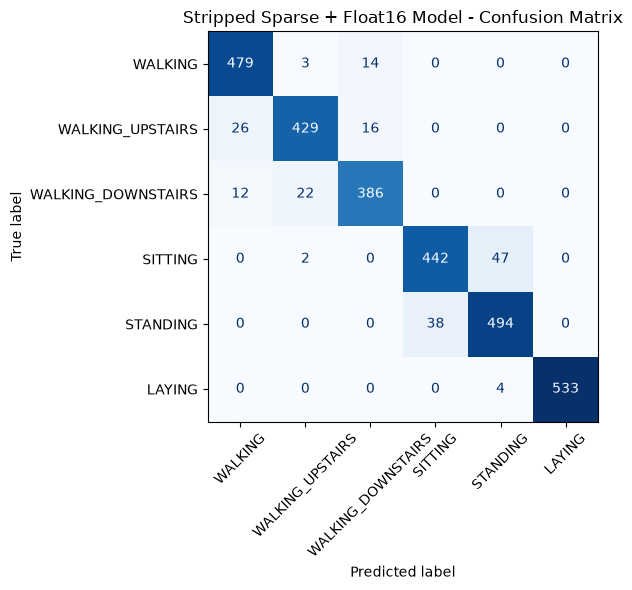

In [38]:
# TODO:
# Plot the confusion matrix for the stripped sparse + float16 TFLite model.
# Print the classification report for the stripped sparse + float16 TFLite model.

# <-- Enter your code here <--#
print(classification_report(y_test, stripped_fp16_preds, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, stripped_fp16_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, xticks_rotation=45, cmap='Blues', colorbar=False)
plt.title('Stripped Sparse + Float16 Model - Confusion Matrix')
plt.tight_layout()
plt.show()

## 13. Summary Questions

Write short answers to the following:
1. Did pruning alone reduce the TensorFlow Lite file size when the pruning wrappers were still attached?

   Ans: No, it made the file bigger (1454 KB) because the wrappers store both weights and masks.
   
3. Why does `strip_pruning(...)` matter before export?

   Ans: It removes the wrappers so only sparse weights remain, letting TFLite encode zeros efficiently.
   
5. Which model had the smallest file size in this notebook?

   Ans: Stripped Sparse + Float16 at ~109 KB.
   
7. Did float16 quantization noticeably change the test accuracy?

   Ans: No, accuracy stayed at 93.76% across all variants.
   
9. If you were deploying this model on a resource-constrained device, which version would you choose and why?

    Ans: Stripped Sparse + Float16 — smallest size and same accuracy as the others.


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- output cells or screenshots showing the comparison tables,
- confusion matrices for the baseline model and your final highlighted compressed model,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors using the **`Python (tinyml-arduino)`** kernel.
